In [2]:
import tensorflow as tf
import numpy as np 
import matplotlib.pyplot as plt
import cv2 
import pandas as pd
from tensorflow import keras


In [3]:
file_path = './data/fer2013.csv'
df = pd.read_csv(file_path)

Extracting the image data form the .csv file


In [4]:
train_data = df[df['Usage'] == 'Training']
val_data = df[df['Usage'] == 'PublicTest']
test_data = df[df['Usage'] == 'PrivateTest']

#To generate a 48*48 image matrix 
def pixel_preprocess(df):
    pixel_series = df['pixels'].apply(lambda x: np.fromstring(x,sep=' ',dtype='float32'))
    x = np.vstack(pixel_series.values)
    x = x.reshape(-1,48,48,1)
    x = x / 255.0
    y = keras.utils.to_categorical(df['emotion'].values,num_classes=7)
    return x, y

X_train, y_train = pixel_preprocess(train_data)
X_val, y_val     = pixel_preprocess(val_data)
X_test, y_test   = pixel_preprocess(test_data)



0: Angry
1: Disgust
2: Fear
3: Happy
4: Sad
5: Surprise
6: Neutral

Visualize the Testing data extracted form the .csv file

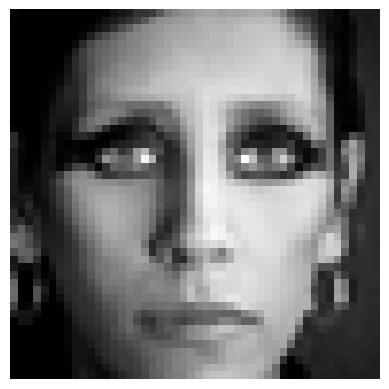

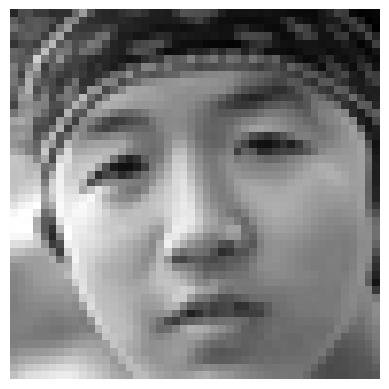

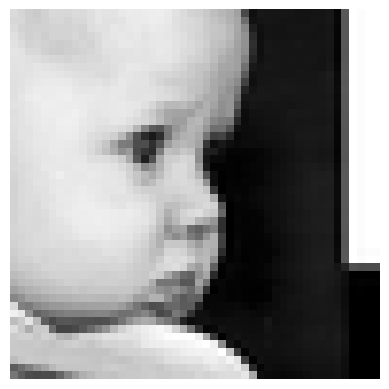

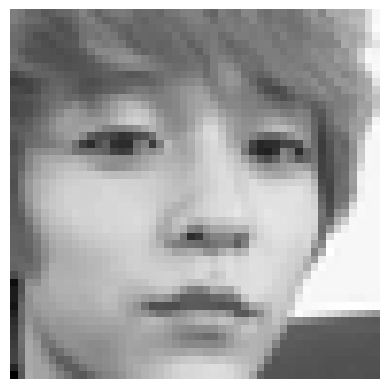

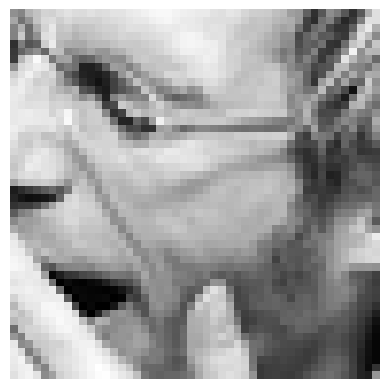

In [5]:
i = 0
for img, label in zip(X_train, y_train):  
    
    if label[6] == 1:
        i += 1
        plt.imshow(img.reshape(48, 48), cmap='gray')
        plt.axis('off')
        plt.show()
        if i >= 5:
            break
    

In [6]:
import pickle 
pickle_out = open('X_train.pickle','wb')
pickle.dump(X_train,pickle_out)
pickle_out = open('y_train.pickle','wb')
pickle.dump(y_train,pickle_out)

pickle_out = open('X_val.pickle','wb')
pickle.dump(X_val,pickle_out)
pickle_out = open('y_val.pickle','wb')
pickle.dump(y_val,pickle_out)

pickle_out = open('X_test.pickle','wb')
pickle.dump(X_test,pickle_out)
pickle_out = open('y_test.pickle','wb')
pickle.dump(y_test,pickle_out)


In [11]:
model = Sequential()

# Block 1
model.add(Conv2D(64, (3,3), padding='same', input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))


# Block 2
model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))


# Block 3
model.add(Conv2D(256, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))


# Dense Layers
model.add(Flatten())

model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.5))

model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.5))


# Output
model.add(Dense(7))
model.add(Activation('softmax'))


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

d:\AI_SEM5\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


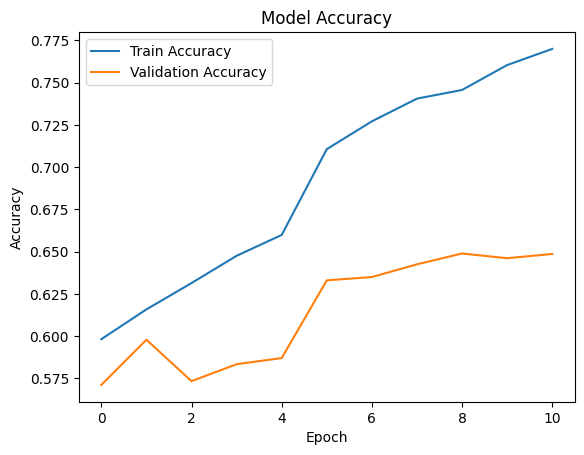

In [24]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

In [20]:
model.save("emotion_detector.h5")

# Grad-CAM: Visualize Model Decision Making

In [ ]:
def visualize_gradcam(image_path):

    def get_gradcam_heatmap(img_array, emotion_idx):
        img_tensor = tf.Variable(img_array, dtype=tf.float32)
        
        with tf.GradientTape() as tape:
            predictions = model(img_tensor)
            target_pred = predictions[0, emotion_idx]
        
        grads = tape.gradient(target_pred, img_tensor)
        
        # Take absolute value and average across channels
        saliency = tf.reduce_mean(tf.abs(grads), axis=-1).numpy()[0]
        
        # Normalize
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
        
        return saliency
    
    # Load and preprocess image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_resized = cv2.resize(gray, (48, 48))
    face_normalized = face_resized / 255.0
    face_reshaped = np.reshape(face_normalized, (1, 48, 48, 1))
    
    # Make prediction
    predictions = model.predict(face_reshaped, verbose=0)
    emotion_idx = np.argmax(predictions)
    emotion = emotion_labels[emotion_idx]
    confidence = predictions[0][emotion_idx] * 100
    
    # Generate Grad-CAM heatmap
    heatmap = get_gradcam_heatmap(face_reshaped, emotion_idx)
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Original image
    axes[0, 0].imshow(face_resized, cmap='gray')
    axes[0, 0].set_title('Original Image (48x48)')
    axes[0, 0].axis('off')
    
    # Heatmap
    im = axes[0, 1].imshow(heatmap, cmap='jet')
    axes[0, 1].set_title(f'Grad-CAM Heatmap\n(What model focused on)')
    axes[0, 1].axis('off')
    plt.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)
    
    # Heatmap overlay on original
    heatmap_resized = cv2.resize(heatmap, (48, 48))
    overlay = (face_resized * 0.6 + heatmap_resized * 0.4 * 255).astype(np.uint8)
    axes[1, 0].imshow(overlay, cmap='gray')
    axes[1, 0].set_title('Overlay: Image + Heatmap')
    axes[1, 0].axis('off')
    
    # Predictions chart
    colors = ['red' if i == emotion_idx else 'blue' for i in range(len(emotion_labels))]
    axes[1, 1].bar(emotion_labels, predictions[0], color=colors)
    axes[1, 1].set_ylabel('Probability')
    axes[1, 1].set_title(f'Emotion: {emotion}\nConfidence: {confidence:.2f}%')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print details
    print(f"\nImage: {image_path}")
    print(f"Detected Emotion: {emotion}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"\nGrad-CAM shows which parts of the face influenced this prediction.")
    print(f"Brighter regions = more important for the '{emotion}' classification.")

## Visualization Using Grad-CAM:

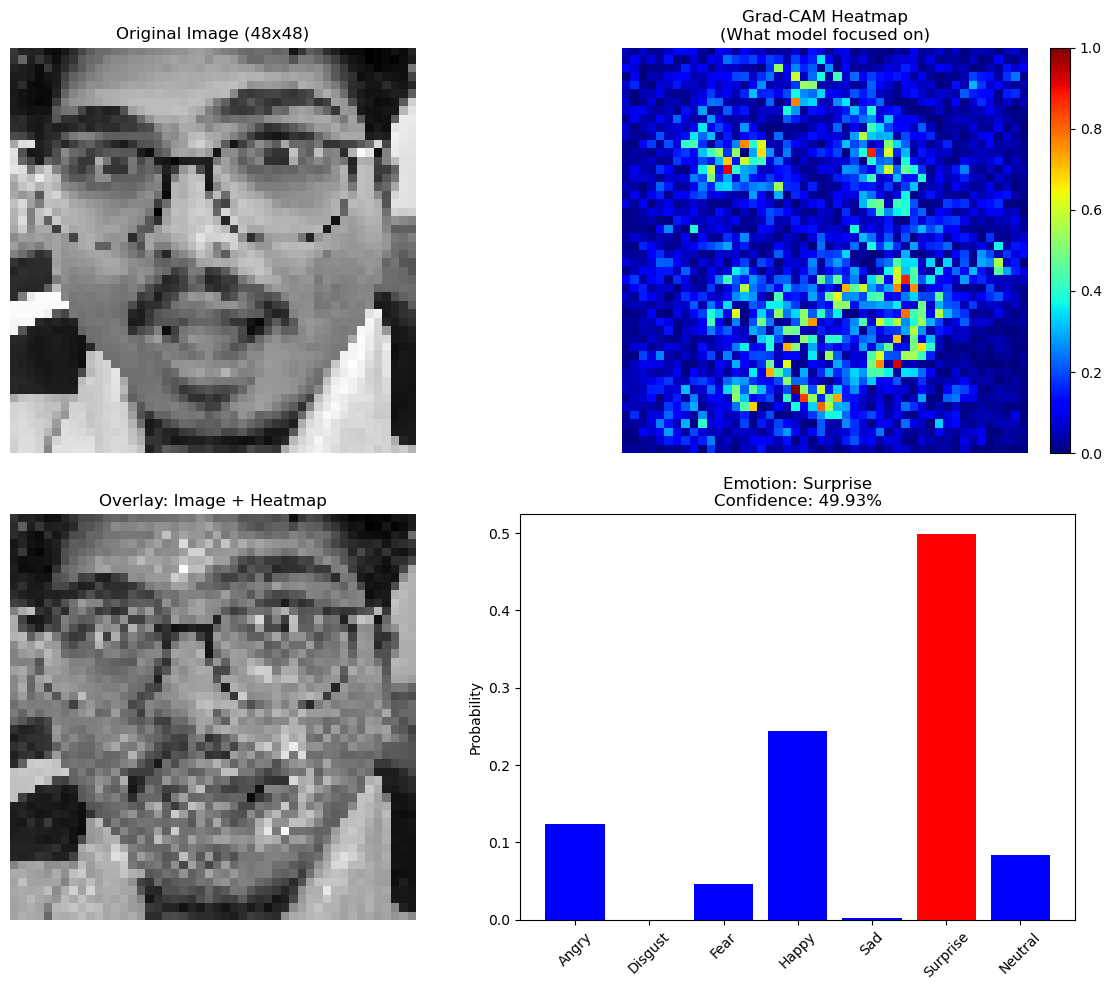


Image: C:\Users\thapa\Documents\080 BEI 008\BEI 5th sem\AI\FACIAL EXPRESSION\AI_FaceEmotion\test-images\Suprised1.png
Detected Emotion: Surprise
Confidence: 49.93%

Grad-CAM shows which parts of the face influenced this prediction.
Brighter regions = more important for the 'Surprise' classification.


In [57]:
# Try Grad-CAM visualization with one of your test images
visualize_gradcam(r"C:\Users\thapa\Documents\080 BEI 008\BEI 5th sem\AI\FACIAL EXPRESSION\AI_FaceEmotion\test-images\Suprised1.png")